<a href="https://colab.research.google.com/github/Amitpaliwal1999/ecommerce-churn-prediction/blob/main/Ecommerce_Churn_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 E-Commerce Customer Churn Prediction
### Complete Python Notebook | Google Colab
---
**Project:** E-Commerce Customer Churn Prediction   
**Dataset:** E_Commerce_Dataset.xlsx — 5,630 customers, 20 features  
**Target:** Churn (1 = churned, 0 = retained) | Overall churn rate: 16.84%



---
## 📦 SECTION 1 — Setup & Data Loading


In [4]:
# ─────────────────────────────────────────────────
# CELL 1 — Upload dataset file
# ─────────────────────────────────────────────────
from google.colab import files

print("Click 'Choose Files' below and select: ecommerce_clean For Python")
uploaded = files.upload()
print("✅ File uploaded successfully!")


Click 'Choose Files' below and select: ecommerce_clean For Python


Saving ecommerce_clean For Python.csv to ecommerce_clean For Python (1).csv
✅ File uploaded successfully!


In [6]:
# ─────────────────────────────────────────────────
# CELL 2 — Install required libraries
# ─────────────────────────────────────────────────
!pip install openpyxl imbalanced-learn xgboost --quiet
print("✅ Libraries installed!")


✅ Libraries installed!


In [7]:
# ─────────────────────────────────────────────────
# CELL 3 — Import all libraries
# ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print("✅ All libraries imported!")
print("pandas:", pd.__version__)


✅ All libraries imported!
pandas: 2.2.2


In [11]:
df = pd.read_csv('ecommerce_clean For Python.csv')

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}  →  {df.shape[0]} customers, {df.shape[1]} columns")
print(f"Churn rate: {df['Churn'].mean()*100:.2f}%  ({df['Churn'].sum()} churned, {(df['Churn']==0).sum()} retained)")
print("\nColumn names:")
print(list(df.columns))
df.head()

✅ Dataset loaded!
Shape: (5630, 20)  →  5630 customers, 20 columns
Churn rate: 16.84%  (948 churned, 4682 retained)

Column names:
['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,Credit Card,Male,3.0,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


---
## 🧹 SECTION 2 — Data Cleaning (Steps 1.1 → 1.3)


In [12]:
# ─────────────────────────────────────────────────
# CELL 5 — Step 1.2: Check & fill missing values
# ─────────────────────────────────────────────────
print("=== NULLS BEFORE FILLING ===")
null_info = df.isnull().sum()
null_info = null_info[null_info > 0]
print(null_info)

# Fill 7 numeric columns with their median
cols_to_fill = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'OrderAmountHikeFromlastYear', 'CouponUsed',
    'OrderCount', 'DaySinceLastOrder'
]
for col in cols_to_fill:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  Filled '{col}' with median = {median_val}")

print("\n=== NULLS AFTER FILLING ===")
remaining = df.isnull().sum().sum()
print(f"Total nulls remaining: {remaining}")
if remaining == 0:
    print("✅ All nulls handled — dataset is complete!")


=== NULLS BEFORE FILLING ===
Series([], dtype: int64)
  Filled 'Tenure' with median = 9.0
  Filled 'WarehouseToHome' with median = 14.0
  Filled 'HourSpendOnApp' with median = 3.0
  Filled 'OrderAmountHikeFromlastYear' with median = 15.0
  Filled 'CouponUsed' with median = 1.0
  Filled 'OrderCount' with median = 2.0
  Filled 'DaySinceLastOrder' with median = 3.0

=== NULLS AFTER FILLING ===
Total nulls remaining: 0
✅ All nulls handled — dataset is complete!


In [13]:
# ─────────────────────────────────────────────────
# CELL 6 — Step 1.3: Fix dirty categorical values
# ─────────────────────────────────────────────────
print("=== BEFORE FIX ===")
print("PaymentMode unique:", df['PreferredPaymentMode'].unique())
print("OrderCat unique   :", df['PreferedOrderCat'].unique())

# Fix 1: PreferredPaymentMode
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC'               : 'Credit Card',
    'Cash on Delivery' : 'COD'
})

# Fix 2: PreferedOrderCat
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({
    'Mobile' : 'Mobile Phone'
})

print("\n=== AFTER FIX ===")
print("PaymentMode counts:")
print(df['PreferredPaymentMode'].value_counts())
print("\nOrderCat counts:")
print(df['PreferedOrderCat'].value_counts())
print("\n✅ Step 1.3 complete — dirty categories fixed!")


=== BEFORE FIX ===
PaymentMode unique: ['Debit Card' 'UPI' 'Credit Card' 'COD' 'E wallet']
OrderCat unique   : ['Laptop & Accessory' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']

=== AFTER FIX ===
PaymentMode counts:
PreferredPaymentMode
Debit Card     2314
Credit Card    1774
E wallet        614
COD             514
UPI             414
Name: count, dtype: int64

OrderCat counts:
PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64

✅ Step 1.3 complete — dirty categories fixed!


In [29]:
# ─────────────────────────────────────────────────
# CELL 7 — Save cleaned dataset (backup)
# ─────────────────────────────────────────────────
df.to_csv('ecommerce_clean.csv', index=False)
print(f"✅ Clean dataset saved as 'ecommerce_clean.csv'")
print(f"   Shape: {df.shape} | Zero nulls confirmed: {df.isnull().sum().sum() == 0}")


✅ Clean dataset saved as 'ecommerce_clean.csv'
   Shape: (5630, 32) | Zero nulls confirmed: True


---
## 📊 SECTION 3 — Exploratory Data Analysis (EDA)


In [15]:
# ─────────────────────────────────────────────────
# CELL 8 — EDA: Summary statistics
# ─────────────────────────────────────────────────
print("=== DATASET OVERVIEW ===")
print(df.describe().round(2))

print("\n=== CHURN BY KEY CATEGORIES ===")
for col in ['Complain', 'MaritalStatus', 'PreferedOrderCat',
            'PreferredPaymentMode', 'CityTier']:
    tbl = df.groupby(col)['Churn'].agg(['mean','count']).round(3)
    tbl.columns = ['Churn Rate', 'Count']
    tbl['Churn Rate'] = (tbl['Churn Rate']*100).round(2).astype(str) + '%'
    print(f"\n{col}:")
    print(tbl)


=== DATASET OVERVIEW ===
       CustomerID    Churn   Tenure  CityTier  WarehouseToHome  \
count     5630.00  5630.00  5630.00   5630.00          5630.00   
mean     52815.50     0.17    10.13      1.65            15.57   
std       1625.39     0.37     8.36      0.92             8.35   
min      50001.00     0.00     0.00      1.00             5.00   
25%      51408.25     0.00     3.00      1.00             9.00   
50%      52815.50     0.00     9.00      1.00            14.00   
75%      54222.75     0.00    15.00      3.00            20.00   
max      55630.00     1.00    61.00      3.00           127.00   

       HourSpendOnApp  NumberOfDeviceRegistered  SatisfactionScore  \
count         5630.00                   5630.00            5630.00   
mean             2.93                      3.69               3.07   
std              0.71                      1.02               1.38   
min              0.00                      1.00               1.00   
25%              2.00         

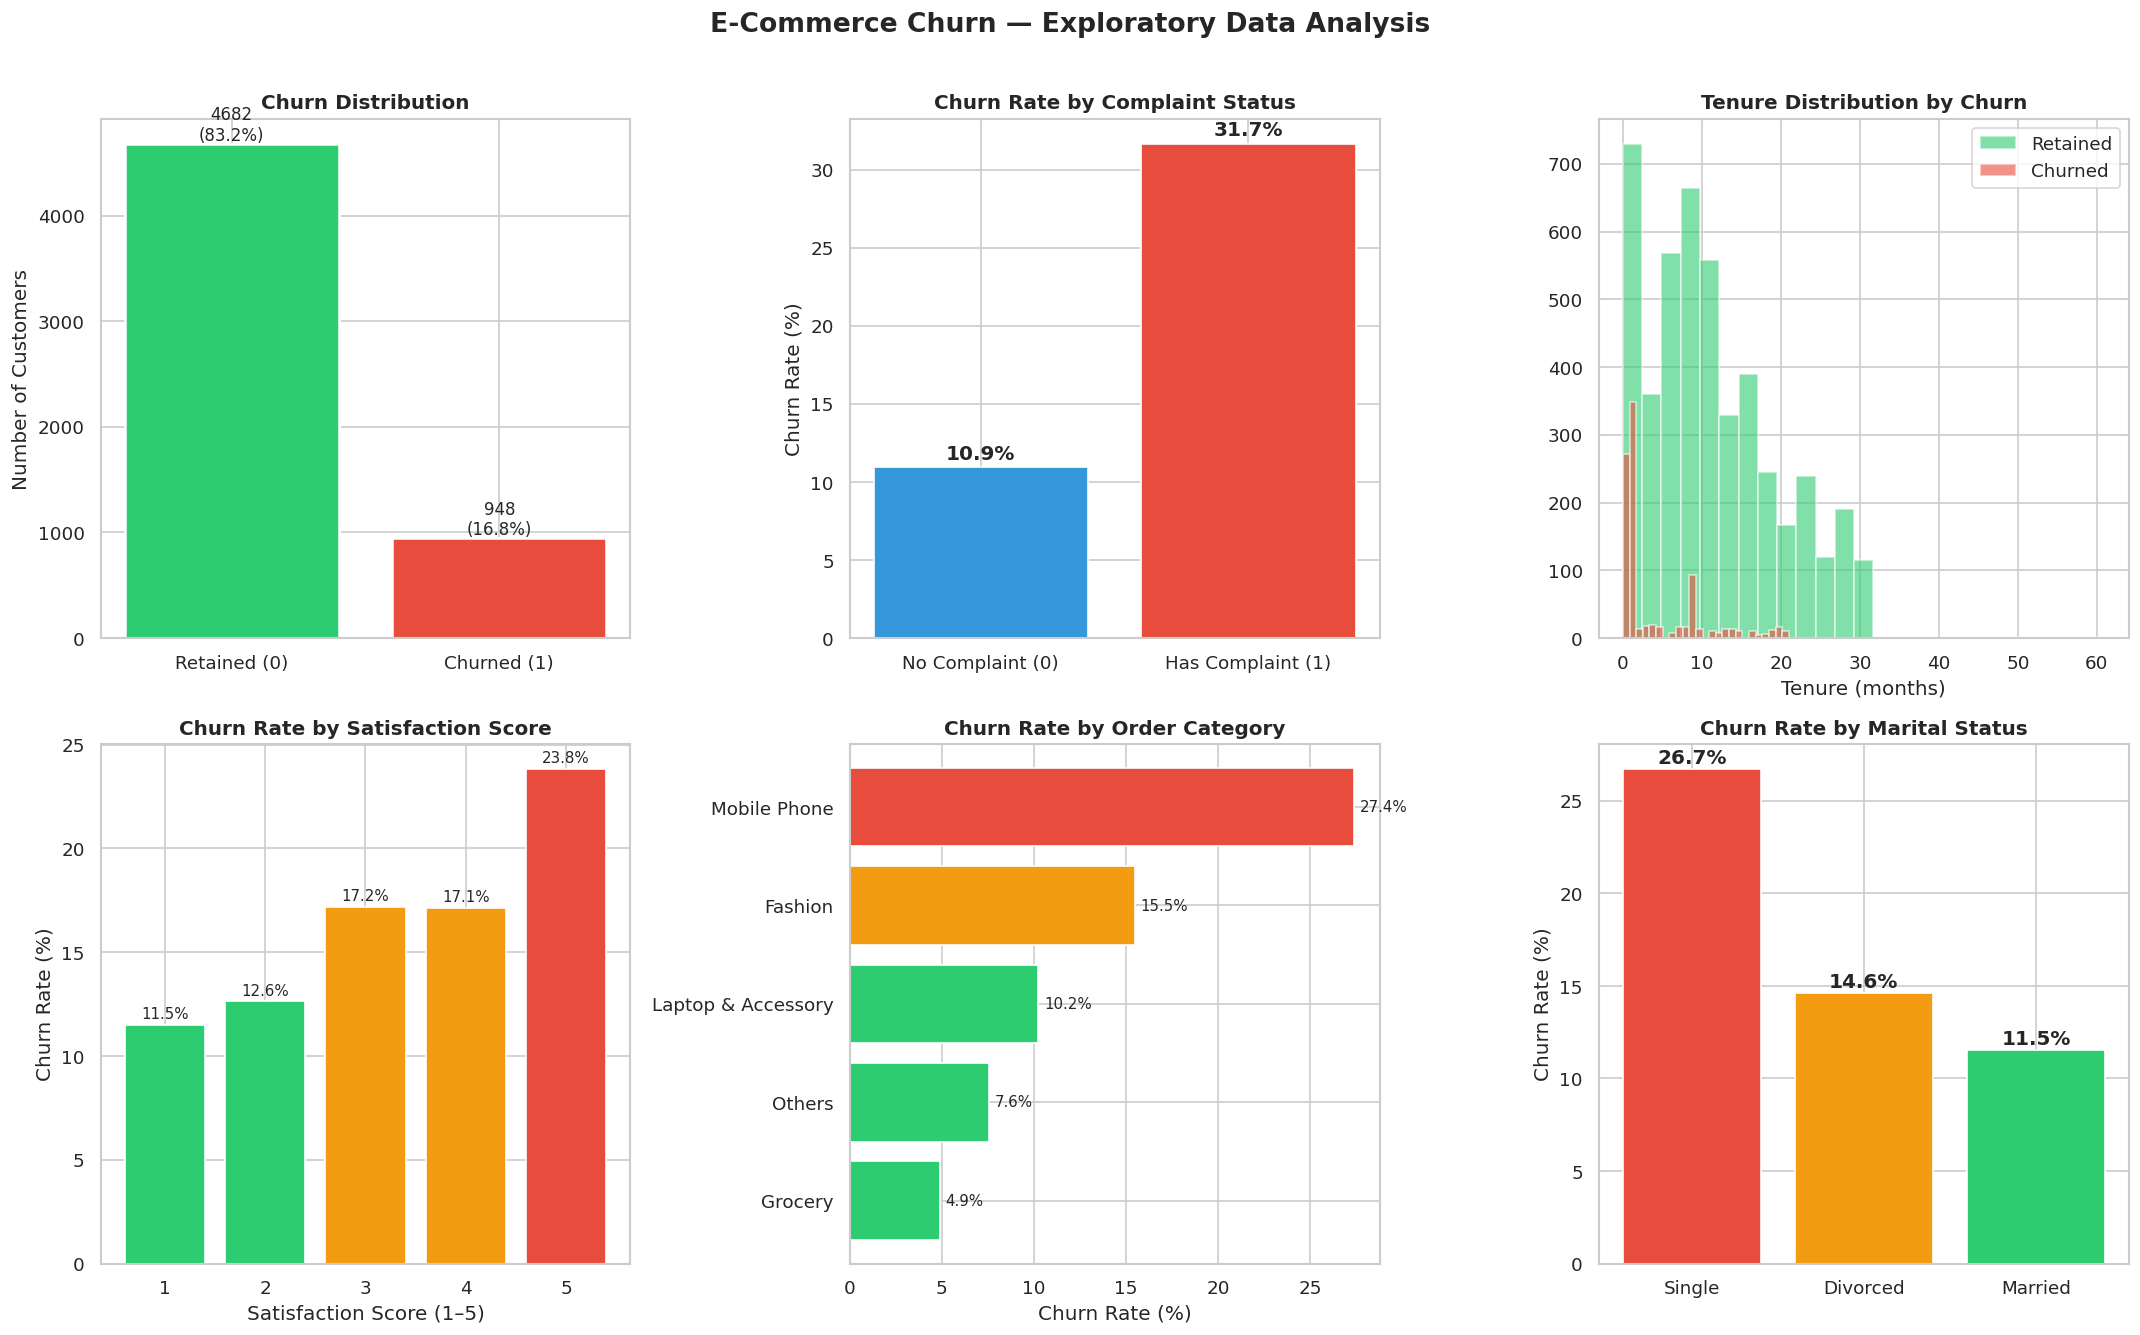

✅ EDA charts saved as 'eda_charts.png'


In [16]:
# ─────────────────────────────────────────────────
# CELL 9 — EDA: 6 visualisation charts
# ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('E-Commerce Churn — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)

colors = ['#2ecc71', '#e74c3c']

# Chart 1: Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0,0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0,0].set_title('Churn Distribution', fontweight='bold')
axes[0,0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0,0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Chart 2: Churn by Complaint
comp_churn = df.groupby('Complain')['Churn'].mean() * 100
axes[0,1].bar(['No Complaint (0)', 'Has Complaint (1)'],
               comp_churn.values, color=['#3498db','#e74c3c'], edgecolor='white')
axes[0,1].set_title('Churn Rate by Complaint Status', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(comp_churn.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 3: Tenure distribution by churn
df[df['Churn']==0]['Tenure'].hist(ax=axes[0,2], bins=25, alpha=0.6, color='#2ecc71', label='Retained')
df[df['Churn']==1]['Tenure'].hist(ax=axes[0,2], bins=25, alpha=0.6, color='#e74c3c', label='Churned')
axes[0,2].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0,2].set_xlabel('Tenure (months)')
axes[0,2].legend()

# Chart 4: Churn by Satisfaction Score
sat_churn = df.groupby('SatisfactionScore')['Churn'].mean() * 100
axes[1,0].bar(sat_churn.index, sat_churn.values,
               color=['#e74c3c' if v > 20 else '#f39c12' if v > 15 else '#2ecc71'
                      for v in sat_churn.values], edgecolor='white')
axes[1,0].set_title('Churn Rate by Satisfaction Score', fontweight='bold')
axes[1,0].set_xlabel('Satisfaction Score (1–5)')
axes[1,0].set_ylabel('Churn Rate (%)')
for i, v in zip(sat_churn.index, sat_churn.values):
    axes[1,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# Chart 5: Churn by Order Category
cat_churn = df.groupby('PreferedOrderCat')['Churn'].mean().sort_values(ascending=True) * 100
axes[1,1].barh(cat_churn.index, cat_churn.values,
                color=['#e74c3c' if v > 20 else '#f39c12' if v > 12 else '#2ecc71'
                       for v in cat_churn.values])
axes[1,1].set_title('Churn Rate by Order Category', fontweight='bold')
axes[1,1].set_xlabel('Churn Rate (%)')
for i, v in enumerate(cat_churn.values):
    axes[1,1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# Chart 6: Churn by Marital Status
mar_churn = df.groupby('MaritalStatus')['Churn'].mean().sort_values(ascending=False) * 100
axes[1,2].bar(mar_churn.index, mar_churn.values,
               color=['#e74c3c','#f39c12','#2ecc71'][:len(mar_churn)], edgecolor='white')
axes[1,2].set_title('Churn Rate by Marital Status', fontweight='bold')
axes[1,2].set_ylabel('Churn Rate (%)')
for i, v in enumerate(mar_churn.values):
    axes[1,2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_charts.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ EDA charts saved as 'eda_charts.png'")


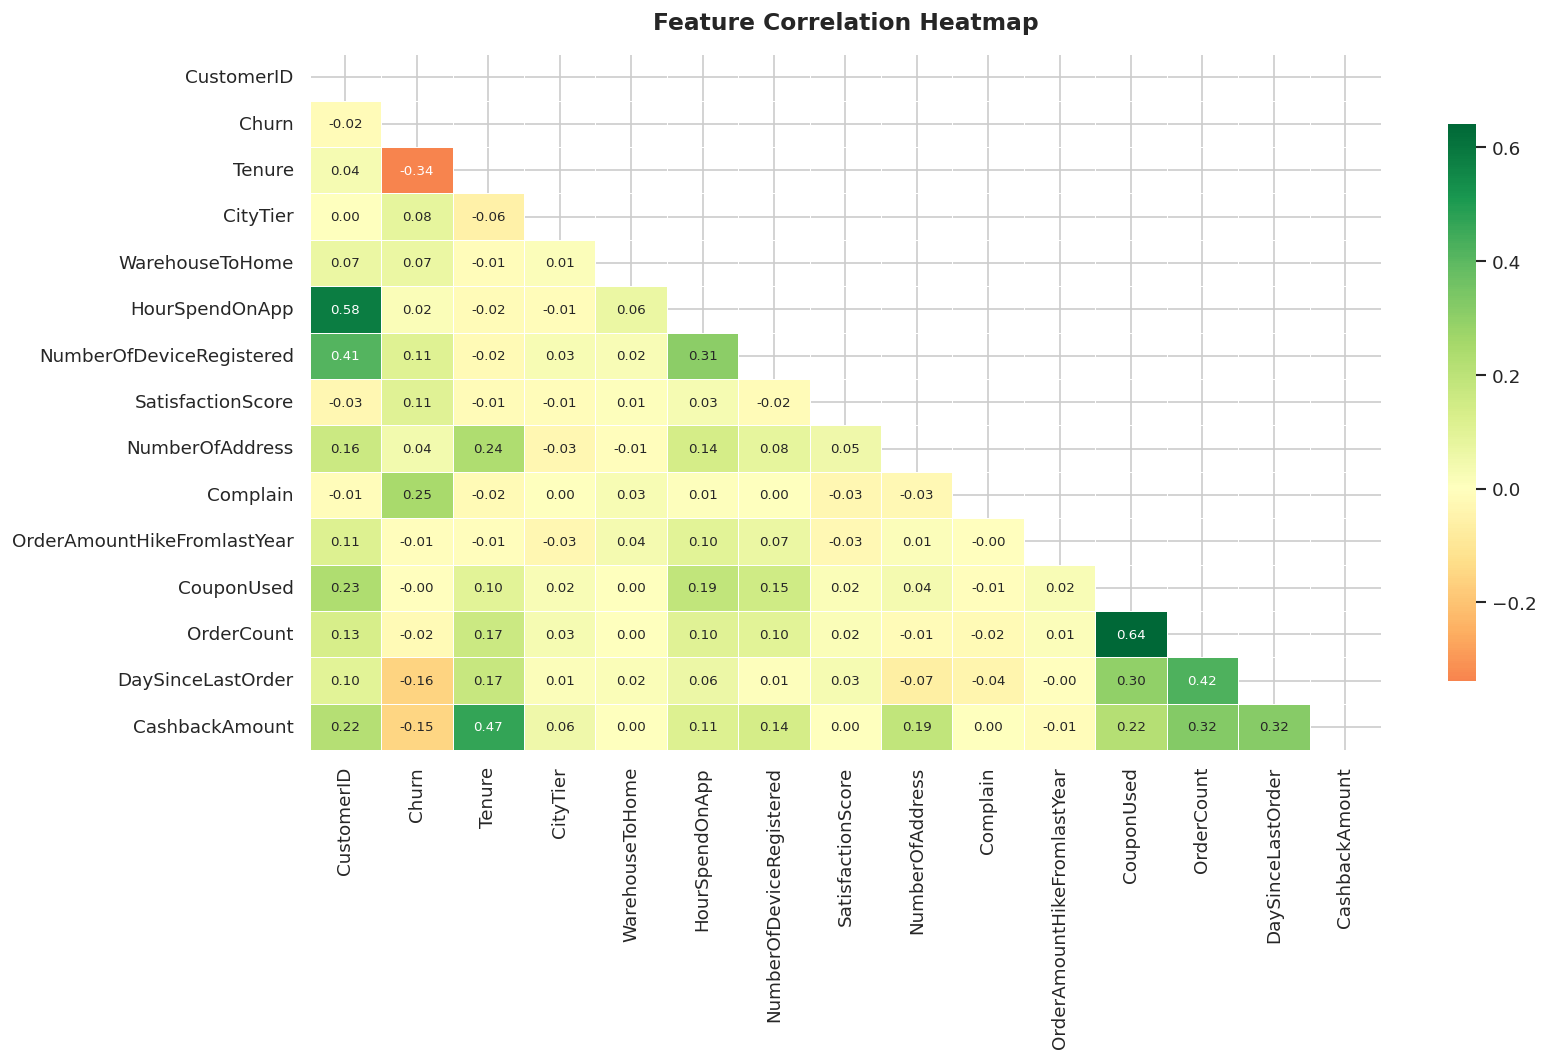

✅ Heatmap saved as 'correlation_heatmap.png'

Top correlations with Churn:
Tenure                     -0.338
Complain                    0.250
DaySinceLastOrder          -0.156
CashbackAmount             -0.154
NumberOfDeviceRegistered    0.108
SatisfactionScore           0.105
CityTier                    0.085
WarehouseToHome             0.070
Name: Churn, dtype: float64


In [17]:
# ─────────────────────────────────────────────────
# CELL 10 — EDA: Correlation heatmap
# ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 9))
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Heatmap saved as 'correlation_heatmap.png'")
print("\nTop correlations with Churn:")
churn_corr = corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(churn_corr.head(8).round(3))


---
## ⚙️ SECTION 4 — Feature Engineering


In [18]:
# ─────────────────────────────────────────────────
# CELL 11 — Feature Engineering: 5 new features + RFM
# ─────────────────────────────────────────────────

# Feature 1: Engagement Score (app hours × orders ÷ recency)
df['EngagementScore'] = (df['HourSpendOnApp'] * df['OrderCount']) / (df['DaySinceLastOrder'] + 1)

# Feature 2: Discount Dependency (coupon usage per order)
df['DiscountDependency'] = df['CouponUsed'] / (df['OrderCount'] + 1)

# Feature 3: Loyalty Score (tenure × order count)
df['LoyaltyScore'] = df['Tenure'] * df['OrderCount']

# Feature 4: High Risk Flag (complained AND low satisfaction)
df['HighRiskFlag'] = ((df['Complain'] == 1) & (df['SatisfactionScore'] <= 2)).astype(int)

# Feature 5: Distance Sensitive (above median warehouse distance)
df['DistanceSensitive'] = (df['WarehouseToHome'] > df['WarehouseToHome'].median()).astype(int)

# RFM Segmentation
df['R_score'] = pd.qcut(df['DaySinceLastOrder'], 4, labels=[4,3,2,1], duplicates='drop').astype(int)
df['F_score'] = pd.qcut(df['OrderCount'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['M_score'] = pd.qcut(df['CashbackAmount'], 4, labels=[1,2,3,4], duplicates='drop').astype(int)
df['RFM_Score'] = df['R_score'] + df['F_score'] + df['M_score']

def rfm_segment(score):
    if score >= 10: return 'Champions'
    elif score >= 8: return 'Loyal'
    elif score >= 6: return 'At Risk'
    elif score >= 4: return 'Hibernating'
    else: return 'Lost'

df['RFM_Segment'] = df['RFM_Score'].apply(rfm_segment)

print("✅ Feature engineering complete!")
print(f"   Dataset now has {df.shape[1]} columns (was 20)")
print("\nNew features created:")
new_feats = ['EngagementScore','DiscountDependency','LoyaltyScore','HighRiskFlag','DistanceSensitive','RFM_Segment']
for f in new_feats:
    print(f"  + {f}")
print("\nRFM Segment distribution:")
print(df['RFM_Segment'].value_counts())
print("\nHigh Risk Flag customers:", df['HighRiskFlag'].sum())


✅ Feature engineering complete!
   Dataset now has 30 columns (was 20)

New features created:
  + EngagementScore
  + DiscountDependency
  + LoyaltyScore
  + HighRiskFlag
  + DistanceSensitive
  + RFM_Segment

RFM Segment distribution:
RFM_Segment
Loyal          2222
At Risk        2129
Champions       773
Hibernating     474
Lost             32
Name: count, dtype: int64

High Risk Flag customers: 542


In [19]:
# ─────────────────────────────────────────────────
# CELL 12 — Export enriched dataset for Tableau/Power BI
# ─────────────────────────────────────────────────
export_cols = ['CustomerID','Churn','Tenure','CityTier','Gender','MaritalStatus',
               'PreferredLoginDevice','PreferredPaymentMode','PreferedOrderCat',
               'SatisfactionScore','Complain','OrderCount','CashbackAmount',
               'DaySinceLastOrder','HourSpendOnApp','WarehouseToHome',
               'EngagementScore','LoyaltyScore','HighRiskFlag',
               'RFM_Score','RFM_Segment']

df[export_cols].to_csv('ecommerce_enriched.csv', index=False)
print("✅ Enriched dataset saved as 'ecommerce_enriched.csv'")
print(f"   {len(export_cols)} columns | {len(df)} rows")
print("   → Use this file in Tableau/Power BI for RFM + CLV dashboards")


✅ Enriched dataset saved as 'ecommerce_enriched.csv'
   21 columns | 5630 rows
   → Use this file in Tableau/Power BI for RFM + CLV dashboards


---
## 🤖 SECTION 5 — Machine Learning Model


In [20]:
# ─────────────────────────────────────────────────
# CELL 13 — Encode categories + train/test split + SMOTE
# ─────────────────────────────────────────────────
df_model = df.copy()

# Label encode categorical columns
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode',
            'Gender', 'PreferedOrderCat', 'MaritalStatus']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Drop non-feature columns
drop_cols = ['CustomerID', 'Churn', 'RFM_Segment']
X = df_model.drop(columns=drop_cols)
y = df_model['Churn']

print(f"Features used for modeling: {X.shape[1]}")
print(list(X.columns))

# Train / test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Churn in train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Churn in test : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# SMOTE — fix class imbalance (16.84% churn is imbalanced)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — Train size: {X_train_res.shape[0]}")
print(f"  Retained: {(y_train_res==0).sum()} | Churned: {(y_train_res==1).sum()}")
print("✅ Data ready for modeling!")


Features used for modeling: 27
['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'EngagementScore', 'DiscountDependency', 'LoyaltyScore', 'HighRiskFlag', 'DistanceSensitive', 'R_score', 'F_score', 'M_score', 'RFM_Score']

Train size: 4504 | Test size: 1126
Churn in train: 758 (16.8%)
Churn in test : 190 (16.9%)

After SMOTE — Train size: 7492
  Retained: 3746 | Churned: 3746
✅ Data ready for modeling!


In [21]:
# ─────────────────────────────────────────────────
# CELL 14 — Train 3 models and compare
# ─────────────────────────────────────────────────
models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=200, eval_metric='logloss',
                                          random_state=42, verbosity=0)
}

results = {}
print("Training models... please wait\n")

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob, 'auc': auc_score}
    print(f"{'='*45}")
    print(f"  {name}  —  ROC-AUC: {auc_score:.4f}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\n🏆 Best model: {best_name}  (AUC = {results[best_name]['auc']:.4f})")


Training models... please wait

  Random Forest  —  ROC-AUC: 0.9889
              precision    recall  f1-score   support

    Retained       0.97      0.98      0.97       936
     Churned       0.88      0.87      0.88       190

    accuracy                           0.96      1126
   macro avg       0.93      0.92      0.93      1126
weighted avg       0.96      0.96      0.96      1126

  Gradient Boosting  —  ROC-AUC: 0.9445
              precision    recall  f1-score   support

    Retained       0.95      0.94      0.95       936
     Churned       0.73      0.75      0.74       190

    accuracy                           0.91      1126
   macro avg       0.84      0.85      0.84      1126
weighted avg       0.91      0.91      0.91      1126

  XGBoost  —  ROC-AUC: 0.9975
              precision    recall  f1-score   support

    Retained       0.99      0.99      0.99       936
     Churned       0.97      0.96      0.97       190

    accuracy                           0.99 

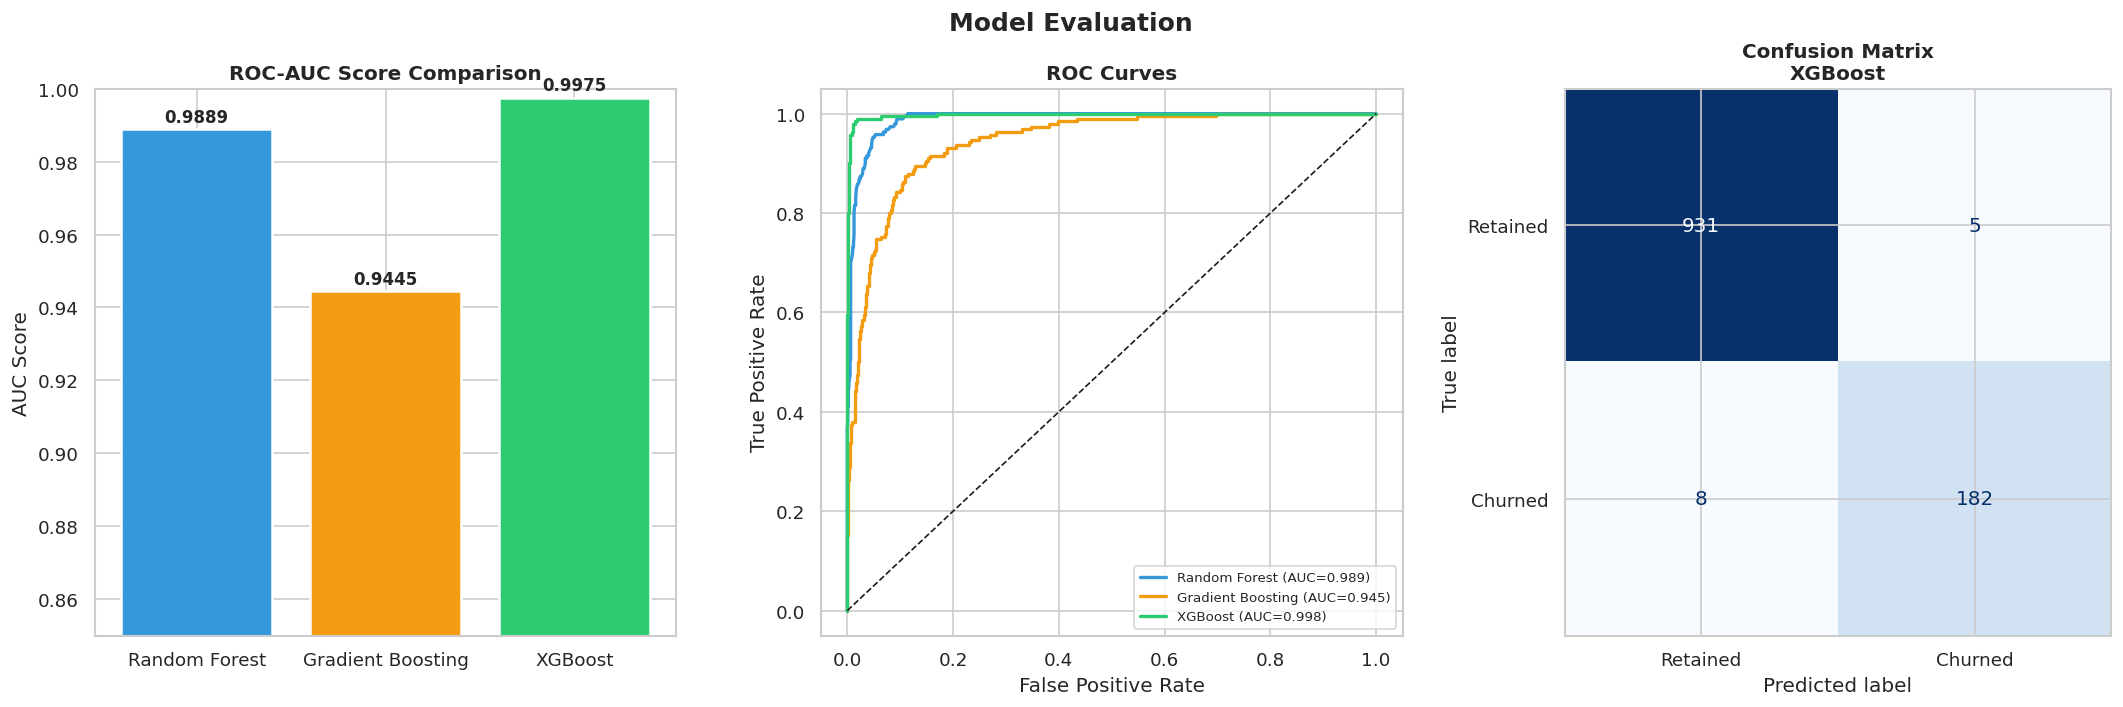

✅ Model comparison chart saved as 'model_comparison.png'


In [22]:
# ─────────────────────────────────────────────────
# CELL 15 — Model comparison charts
# ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Evaluation', fontsize=15, fontweight='bold')

# 1. AUC comparison bar chart
model_names = list(results.keys())
auc_scores  = [results[n]['auc'] for n in model_names]
bars = axes[0].bar(model_names, auc_scores,
                    color=['#3498db','#f39c12','#2ecc71'], edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0.85, 1.0)
axes[0].set_title('ROC-AUC Score Comparison', fontweight='bold')
axes[0].set_ylabel('AUC Score')
for bar, score in zip(bars, auc_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                  f'{score:.4f}', ha='center', fontweight='bold', fontsize=10)

# 2. ROC Curves
for name, color in zip(model_names, ['#3498db','#f39c12','#2ecc71']):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    axes[1].plot(fpr, tpr, color=color, lw=2,
                  label=f"{name} (AUC={results[name]['auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves', fontweight='bold')
axes[1].legend(fontsize=8)

# 3. Confusion matrix of best model
best_name = max(results, key=lambda k: results[k]['auc'])
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned']).plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"✅ Model comparison chart saved as 'model_comparison.png'")


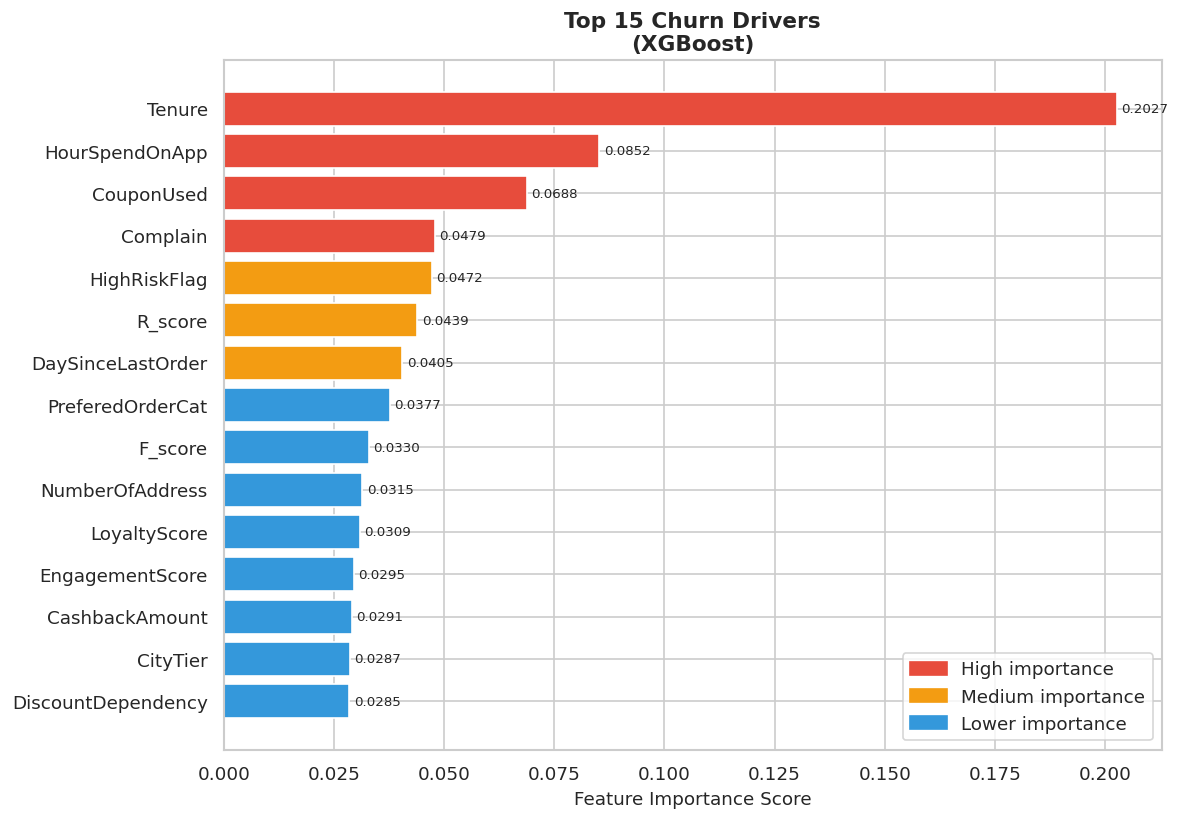

✅ Feature importance chart saved as 'feature_importance.png'

Top 10 churn drivers:
Tenure               0.2027
HourSpendOnApp       0.0852
CouponUsed           0.0688
Complain             0.0479
HighRiskFlag         0.0472
R_score              0.0439
DaySinceLastOrder    0.0405
PreferedOrderCat     0.0377
F_score              0.0330
NumberOfAddress      0.0315
dtype: float32


In [23]:
# ─────────────────────────────────────────────────
# CELL 16 — Feature importance chart
# ─────────────────────────────────────────────────
best_model = results[best_name]['model']
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#e74c3c' if v > feat_imp_sorted.quantile(0.75)
               else '#f39c12' if v > feat_imp_sorted.quantile(0.5)
               else '#3498db' for v in feat_imp_sorted.values]
bars = ax.barh(feat_imp_sorted.index, feat_imp_sorted.values, color=colors_imp, edgecolor='white')
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title(f'Top 15 Churn Drivers\n({best_name})', fontsize=13, fontweight='bold')
for bar, val in zip(bars, feat_imp_sorted.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)
red_patch   = mpatches.Patch(color='#e74c3c', label='High importance')
amber_patch = mpatches.Patch(color='#f39c12', label='Medium importance')
blue_patch  = mpatches.Patch(color='#3498db', label='Lower importance')
ax.legend(handles=[red_patch, amber_patch, blue_patch], loc='lower right')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Feature importance chart saved as 'feature_importance.png'")
print("\nTop 10 churn drivers:")
print(feat_imp.sort_values(ascending=False).head(10).round(4))


---
## 🎯 SECTION 6 — Churn Probability Scoring


In [24]:
# ─────────────────────────────────────────────────
# CELL 17 — Score every customer with churn probability
# ─────────────────────────────────────────────────
best_model = results[best_name]['model']

# Score all 5630 customers
df_score = df.copy()
cat_cols = ['PreferredLoginDevice','PreferredPaymentMode',
            'Gender','PreferedOrderCat','MaritalStatus']
le2 = LabelEncoder()
df_score_enc = df_score.copy()
for col in cat_cols:
    df_score_enc[col] = le2.fit_transform(df_score_enc[col])

X_all = df_score_enc.drop(columns=['CustomerID','Churn','RFM_Segment'])
df['ChurnProbability'] = best_model.predict_proba(X_all)[:, 1]
df['ChurnRiskTier'] = pd.cut(df['ChurnProbability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'])

print("✅ All customers scored!")
print("\nRisk Tier distribution:")
print(df['ChurnRiskTier'].value_counts())
print(f"\nHigh Risk customers: {(df['ChurnRiskTier']=='High Risk').sum()}")
print(f"Medium Risk        : {(df['ChurnRiskTier']=='Medium Risk').sum()}")
print(f"Low Risk           : {(df['ChurnRiskTier']=='Low Risk').sum()}")


✅ All customers scored!

Risk Tier distribution:
ChurnRiskTier
Low Risk       4676
High Risk       941
Medium Risk      13
Name: count, dtype: int64

High Risk customers: 941
Medium Risk        : 13
Low Risk           : 4676


In [25]:
# ─────────────────────────────────────────────────
# CELL 18 — Export churn scores for Tableau/Power BI
# ─────────────────────────────────────────────────
churn_scores = df[[
    'CustomerID', 'Churn', 'ChurnProbability', 'ChurnRiskTier',
    'Tenure', 'CashbackAmount', 'OrderCount', 'SatisfactionScore',
    'Complain', 'MaritalStatus', 'PreferedOrderCat',
    'PreferredPaymentMode', 'CityTier', 'RFM_Segment',
    'EngagementScore', 'LoyaltyScore', 'HighRiskFlag'
]].copy()

churn_scores['ChurnProbability'] = churn_scores['ChurnProbability'].round(4)
churn_scores = churn_scores.sort_values('ChurnProbability', ascending=False)
churn_scores.to_csv('churn_scores.csv', index=False)

print("✅ Churn scores exported as 'churn_scores.csv'")
print(f"   {len(churn_scores)} customers scored")
print("\nTop 10 highest churn risk customers:")
print(churn_scores[['CustomerID','ChurnProbability','ChurnRiskTier',
                      'CashbackAmount','Complain','SatisfactionScore']].head(10).to_string(index=False))


✅ Churn scores exported as 'churn_scores.csv'
   5630 customers scored

Top 10 highest churn risk customers:
 CustomerID  ChurnProbability ChurnRiskTier  CashbackAmount  Complain  SatisfactionScore
      55397               1.0     High Risk          186.34         1                  5
      51245               1.0     High Risk          198.54         1                  3
      55158               1.0     High Risk          148.94         1                  3
      55500               1.0     High Risk          149.72         1                  4
      55493               1.0     High Risk          149.39         1                  1
      55487               1.0     High Risk          224.07         1                  4
      55093               1.0     High Risk          158.39         1                  3
      53623               1.0     High Risk          158.39         1                  3
      53927               1.0     High Risk          186.34         1                  5
 

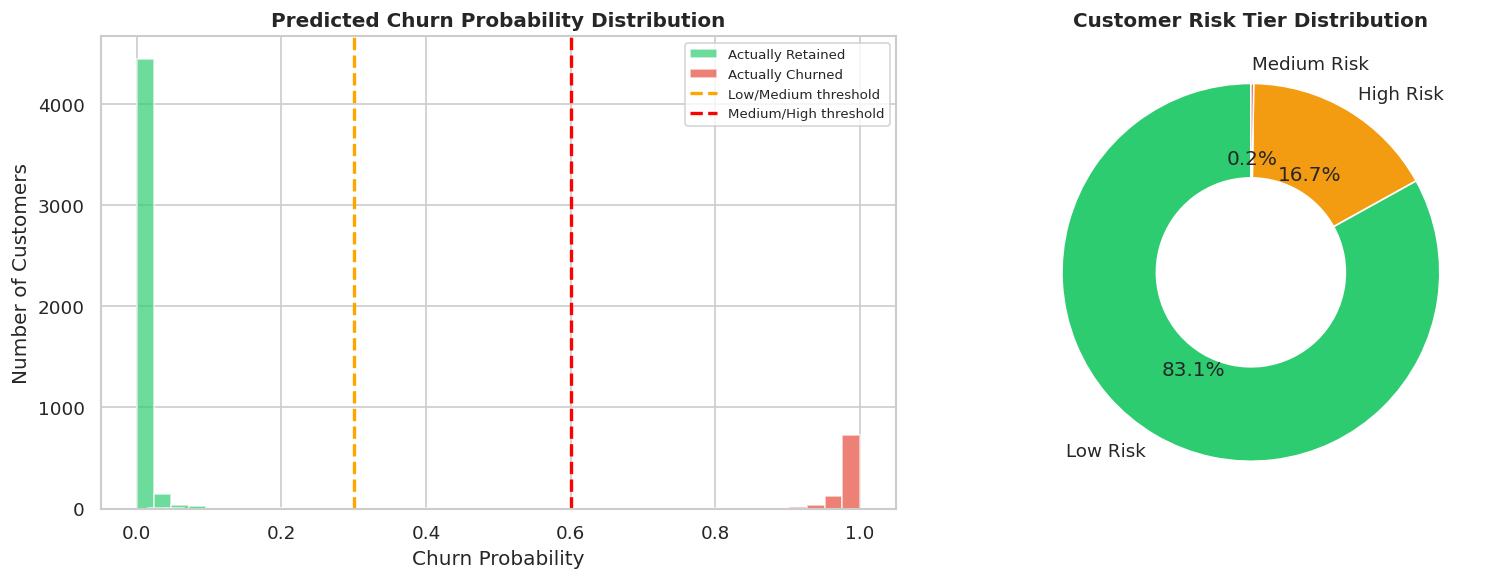

✅ Chart saved as 'churn_probability_dist.png'


In [26]:
# ─────────────────────────────────────────────────
# CELL 19 — Churn probability distribution chart
# ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: probability histogram
axes[0].hist(df[df['Churn']==0]['ChurnProbability'], bins=40, alpha=0.7,
              color='#2ecc71', label='Actually Retained')
axes[0].hist(df[df['Churn']==1]['ChurnProbability'], bins=40, alpha=0.7,
              color='#e74c3c', label='Actually Churned')
axes[0].axvline(0.3, color='orange', linestyle='--', lw=2, label='Low/Medium threshold')
axes[0].axvline(0.6, color='red',    linestyle='--', lw=2, label='Medium/High threshold')
axes[0].set_xlabel('Churn Probability')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Predicted Churn Probability Distribution', fontweight='bold')
axes[0].legend(fontsize=8)

# Right: Risk tier donut
tier_counts = df['ChurnRiskTier'].value_counts()
donut_colors = ['#2ecc71','#f39c12','#e74c3c']
wedges, texts, autotexts = axes[1].pie(
    tier_counts.values, labels=tier_counts.index,
    autopct='%1.1f%%', colors=donut_colors,
    wedgeprops={'width':0.5}, startangle=90)
axes[1].set_title('Customer Risk Tier Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_probability_dist.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart saved as 'churn_probability_dist.png'")


---
## 📋 SECTION 7 — Business Insights & Final Export


In [27]:
# ─────────────────────────────────────────────────
# CELL 20 — Key business insights from the data
# ─────────────────────────────────────────────────
print("=" * 60)
print("  KEY BUSINESS INSIGHTS — E-COMMERCE CHURN PROJECT")
print("=" * 60)

print(f"\n1. OVERALL CHURN RATE")
print(f"   {df['Churn'].mean()*100:.2f}% of customers churned ({df['Churn'].sum()} out of {len(df)})")

print(f"\n2. COMPLAINT IMPACT (Biggest churn driver)")
for v in [0,1]:
    rate = df[df['Complain']==v]['Churn'].mean()*100
    print(f"   Complaint={v}: {rate:.1f}% churn rate")

print(f"\n3. CHURN BY MARITAL STATUS")
for ms, g in df.groupby('MaritalStatus'):
    print(f"   {ms}: {g['Churn'].mean()*100:.1f}% churn ({len(g)} customers)")

print(f"\n4. CHURN BY ORDER CATEGORY")
cat_ch = df.groupby('PreferedOrderCat')['Churn'].mean().sort_values(ascending=False)*100
for cat, rate in cat_ch.items():
    print(f"   {cat}: {rate:.1f}%")

print(f"\n5. CHURN BY PAYMENT MODE")
pay_ch = df.groupby('PreferredPaymentMode')['Churn'].mean().sort_values(ascending=False)*100
for pay, rate in pay_ch.items():
    print(f"   {pay}: {rate:.1f}%")

print(f"\n6. HIGH-RISK CUSTOMERS IDENTIFIED")
high_risk = df[(df['ChurnRiskTier']=='High Risk') & (df['Churn']==0)]
print(f"   {len(high_risk)} active customers with HIGH churn probability")
print(f"   Avg cashback value: ${high_risk['CashbackAmount'].mean():.2f}")
print(f"   → These are your priority retention targets!")

print(f"\n7. MODEL PERFORMANCE ({best_name})")
print(f"   ROC-AUC Score: {results[best_name]['auc']:.4f}")
print("=" * 60)


  KEY BUSINESS INSIGHTS — E-COMMERCE CHURN PROJECT

1. OVERALL CHURN RATE
   16.84% of customers churned (948 out of 5630)

2. COMPLAINT IMPACT (Biggest churn driver)
   Complaint=0: 10.9% churn rate
   Complaint=1: 31.7% churn rate

3. CHURN BY MARITAL STATUS
   Divorced: 14.6% churn (848 customers)
   Married: 11.5% churn (2986 customers)
   Single: 26.7% churn (1796 customers)

4. CHURN BY ORDER CATEGORY
   Mobile Phone: 27.4%
   Fashion: 15.5%
   Laptop & Accessory: 10.2%
   Others: 7.6%
   Grocery: 4.9%

5. CHURN BY PAYMENT MODE
   COD: 24.9%
   E wallet: 22.8%
   UPI: 17.4%
   Debit Card: 15.4%
   Credit Card: 14.2%

6. HIGH-RISK CUSTOMERS IDENTIFIED
   5 active customers with HIGH churn probability
   Avg cashback value: $149.21
   → These are your priority retention targets!

7. MODEL PERFORMANCE (XGBoost)
   ROC-AUC Score: 0.9975


In [28]:
# ─────────────────────────────────────────────────
# CELL 21 — Download all output files
# ─────────────────────────────────────────────────
from google.colab import files

output_files = [
    ('ecommerce_clean.csv',         'Cleaned dataset'),
    ('ecommerce_enriched.csv',      'Dataset with RFM + new features → for Tableau'),
    ('churn_scores.csv',            'Churn probability scores → for Dashboard 6'),
    ('eda_charts.png',              'EDA visualisations'),
    ('correlation_heatmap.png',     'Correlation heatmap'),
    ('model_comparison.png',        'Model comparison + ROC curves'),
    ('feature_importance.png',      'Top churn drivers chart'),
    ('churn_probability_dist.png',  'Churn probability distribution'),
]

print("Downloading all output files...\n")
for fname, desc in output_files:
    try:
        files.download(fname)
        print(f"✅ {fname}  —  {desc}")
    except Exception as e:
        print(f"⚠️  {fname} not found — make sure all cells above were run")

print("\n🎉 All done! Import CSV files into Tableau/Power BI to build your 6 dashboards.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ ecommerce_clean.csv  —  Cleaned dataset


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ feature_importance.png  —  Top churn drivers chart


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ churn_probability_dist.png  —  Churn probability distribution

🎉 All done! Import CSV files into Tableau/Power BI to build your 6 dashboards.
